In [66]:
# Tiến hành import thư viện để xử lí
import pandas as pd
import numpy as np
import json
from sqlalchemy import create_engine
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [67]:
engine = create_engine("sqlite:///../data/sample_strategy/sample_v4.db")

In [68]:
tables = ['cardiovascular_diseases', 'air_pollution', 'alcohol_consumption', 'BMI', 'cholesterol', 'diabetes', 'glucose', 'physical_activities', 'tobacco', 'country', 'time']

In [69]:
df = pd.read_sql('select * from NearsestSample where TimeDim >= 2010 AND TimeDim <=2015 order by TimeDim', engine)
df.drop(columns=['id', 'x7'], inplace=True)
df.head()

,y,x1,x2,x3,x4,x5,x6,x8,x9,SpatialDim,TimeDim
0,134.9,29.965,23.820369,26.100000,5.0,7.20000,7.9,24.705610,28.1,ALB,2010
1,129.3,318.519,12.069340,25.800000,3.8,6.90000,7.6,17.618408,47.9,ALB,2010
2,49.2,297.474,19.085258,26.400000,1.3,7.10000,7.7,21.201094,8.3,ALB,2010
3,36.9,1082.913,33.698791,16.569351,5.0,5.07143,7.5,21.049074,8.3,ALB,2010
4,25.3,583.170,24.439932,13.953908,3.5,4.97745,8.2,24.492598,8.3,ALB,2010


In [70]:
df.columns = tables

In [71]:
df.head(n=50)

,cardiovascular_diseases,air_pollution,alcohol_consumption,BMI,cholesterol,diabetes,glucose,physical_activities,tobacco,country,time
0,134.900000,29.965,23.820369,26.100000,5.0,7.200000,7.9,24.705610,28.1,ALB,2010
1,129.300000,318.519,12.069340,25.800000,3.8,6.900000,7.6,17.618408,47.9,ALB,2010
2,49.200000,297.474,19.085258,26.400000,1.3,7.100000,7.7,21.201094,8.3,ALB,2010
3,36.900000,1082.913,33.698791,16.569351,5.0,5.071430,7.5,21.049074,8.3,ALB,2010
4,25.300000,583.170,24.439932,13.953908,3.5,4.977450,8.2,24.492598,8.3,ALB,2010
5,41.500000,422.434,42.813365,19.130212,1.5,48.989427,7.2,24.987326,8.3,ALB,2010
6,43.300000,53.454,19.083246,2.155009,5.0,50.822610,7.6,24.705610,8.3,ALB,2010
7,40.000000,67.601,12.260685,0.690832,3.6,49.853790,7.4,17.406889,8.3,ALB,2010
8,39.094204,78.196,18.533113,1.408874,1.4,7.000000,7.7,17.618408,8.3,ALB,2010
9,36.871685,1337.990,23.017992,52.693850,3.8,6.900000,7.8,20.912361,8.3,ALB,2010


In [72]:
# Thử in mô tả dữ liệu
df.describe()

,cardiovascular_diseases,air_pollution,alcohol_consumption,BMI,cholesterol,diabetes,glucose,physical_activities,tobacco,time
count,10956.000000,1.089000e+04,10735.000000,10956.000000,10956.000000,10956.000000,10956.000000,10956.000000,10956.000000,10956.000000
mean,55.593244,8.290686e+03,41.429338,22.424149,2.903514,16.683322,8.657804,26.063816,23.755696,2012.500000
std,35.512469,3.204996e+05,19.454759,17.616987,1.426160,16.735358,4.239293,11.766169,14.737694,1.707903
min,8.701838,0.000000e+00,2.680089,0.238787,0.800000,2.800000,2.100000,3.335438,0.000000,2010.000000
25%,32.768090,5.062125e+01,26.365584,7.450371,1.300000,5.694480,5.900000,17.580842,12.475000,2011.000000
50%,40.400000,1.898935e+02,39.582456,22.200000,3.300000,8.000000,8.000000,23.772923,23.000000,2012.500000
75%,62.100000,5.717755e+02,52.716017,27.200000,4.000000,20.600000,9.800000,32.636906,32.800000,2014.000000
max,137.500000,2.509519e+07,99.215604,92.470789,5.300000,83.102876,29.800000,69.205147,77.000000,2015.000000


In [73]:
# Thử tiến hành bỏ qua các giá trị NULL
df.dropna(inplace=True)

In [74]:
df.describe()

,cardiovascular_diseases,air_pollution,alcohol_consumption,BMI,cholesterol,diabetes,glucose,physical_activities,tobacco,time
count,10691.000000,1.069100e+04,10691.000000,10691.000000,10691.000000,10691.000000,10691.000000,10691.000000,10691.000000,10691.000000
mean,55.473927,8.432686e+03,41.388007,22.249093,2.900412,16.580953,8.467000,25.920530,23.532074,2012.493125
std,35.485842,3.234664e+05,19.457852,17.418566,1.423578,16.741152,3.958809,11.778066,14.762403,1.706046
min,8.701838,0.000000e+00,2.680089,0.238787,0.800000,2.800000,2.100000,3.335438,0.000000,2010.000000
25%,32.700000,5.244500e+01,26.348938,7.453217,1.300000,5.662990,5.900000,17.473626,12.200000,2011.000000
50%,40.233006,1.946850e+02,39.549579,22.100000,3.300000,8.000000,8.000000,23.655035,22.700000,2012.000000
75%,62.100000,5.751635e+02,52.674641,27.100000,4.000000,19.688574,9.700000,32.457369,32.500000,2014.000000
max,137.500000,2.509519e+07,99.215604,92.470789,5.300000,83.102876,29.800000,69.205147,77.000000,2015.000000


In [75]:
# Thử in lại một số điểm đầu của dữ liệu
df.head()

,cardiovascular_diseases,air_pollution,alcohol_consumption,BMI,cholesterol,diabetes,glucose,physical_activities,tobacco,country,time
0,134.9,29.965,23.820369,26.100000,5.0,7.20000,7.9,24.705610,28.1,ALB,2010
1,129.3,318.519,12.069340,25.800000,3.8,6.90000,7.6,17.618408,47.9,ALB,2010
2,49.2,297.474,19.085258,26.400000,1.3,7.10000,7.7,21.201094,8.3,ALB,2010
3,36.9,1082.913,33.698791,16.569351,5.0,5.07143,7.5,21.049074,8.3,ALB,2010
4,25.3,583.170,24.439932,13.953908,3.5,4.97745,8.2,24.492598,8.3,ALB,2010


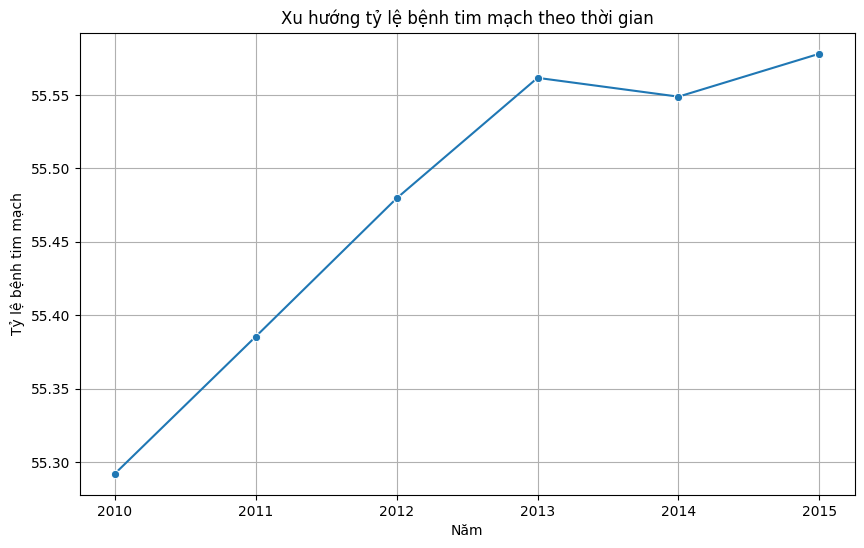

In [76]:
# %%
# Biểu đồ xu hướng tỷ lệ bệnh tim mạch theo thời gian

trend = (
    df.groupby("time")["cardiovascular_diseases"]
    .mean()
    .reset_index()
    .sort_values("time")
)

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=trend,
    x="time",
    y="cardiovascular_diseases",
    marker="o"
)

plt.title("Xu hướng tỷ lệ bệnh tim mạch theo thời gian")
plt.xlabel("Năm")
plt.ylabel("Tỷ lệ bệnh tim mạch")
plt.grid(True)

plt.show()

In [77]:
def draw_histogram(column):
    var = df[column]
    plt.figure(figsize=(6, 4))
    sns.histplot(var, kde=True)
    plt.title(f"Phân phối dữ liệu của {column}")
    plt.ylabel("Số lượng")
    plt.xlabel("Biên độ giá trị")
    plt.show()

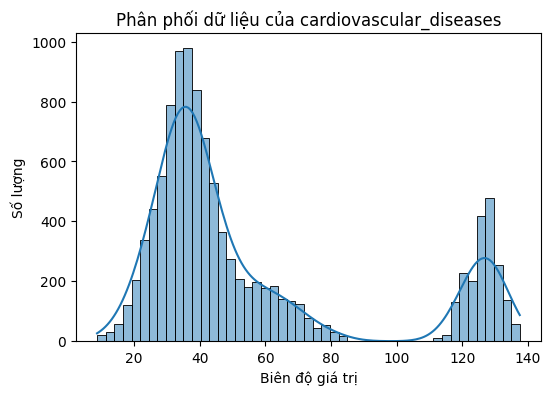

In [78]:
draw_histogram('cardiovascular_diseases')

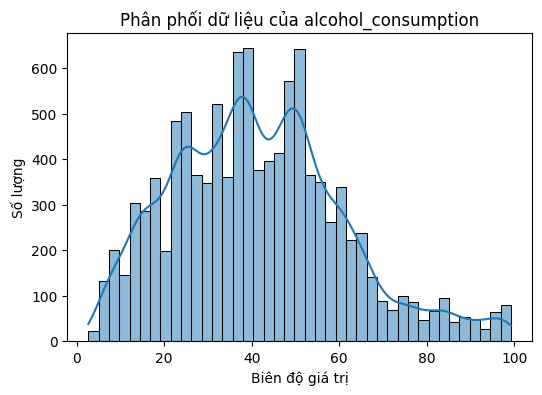

In [79]:
draw_histogram('alcohol_consumption')

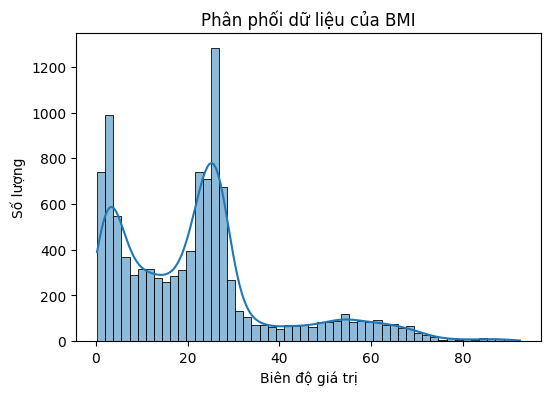

In [80]:
draw_histogram('BMI')

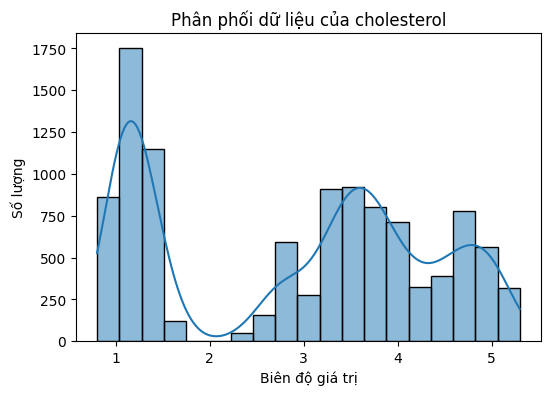

In [81]:
draw_histogram('cholesterol')

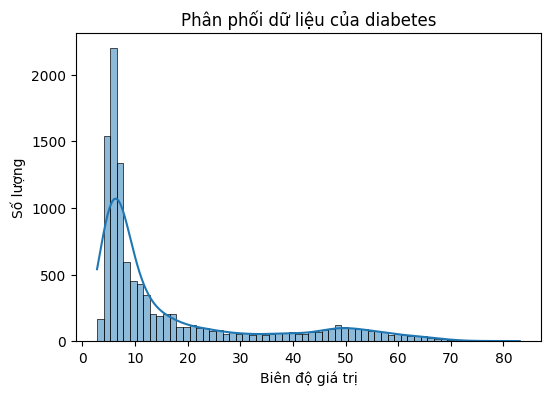

In [82]:
draw_histogram('diabetes')

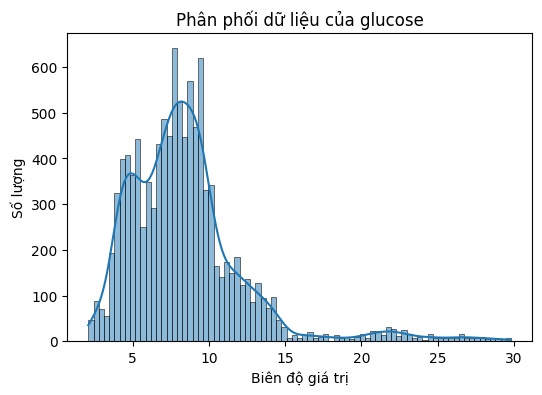

In [83]:
draw_histogram('glucose')

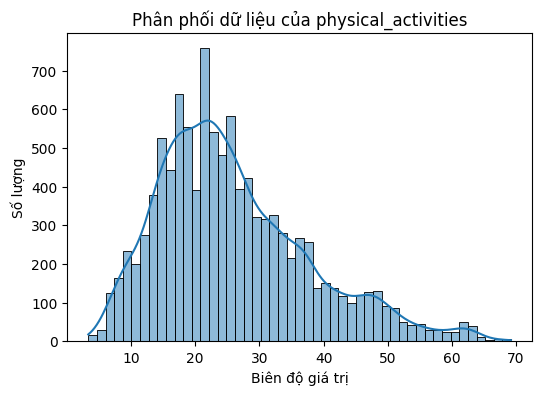

In [84]:
draw_histogram('physical_activities')

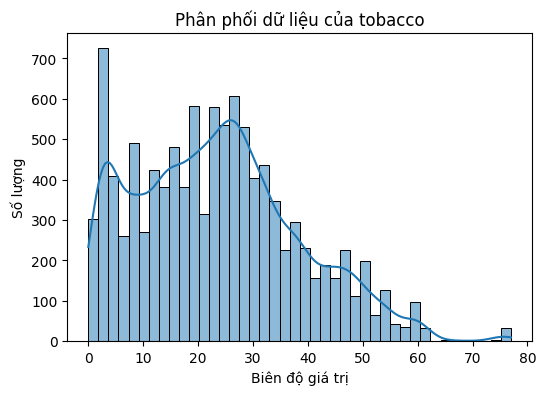

In [85]:
draw_histogram('tobacco')

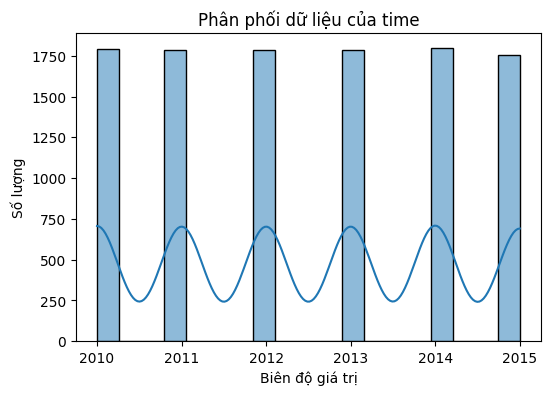

In [86]:
draw_histogram('time')

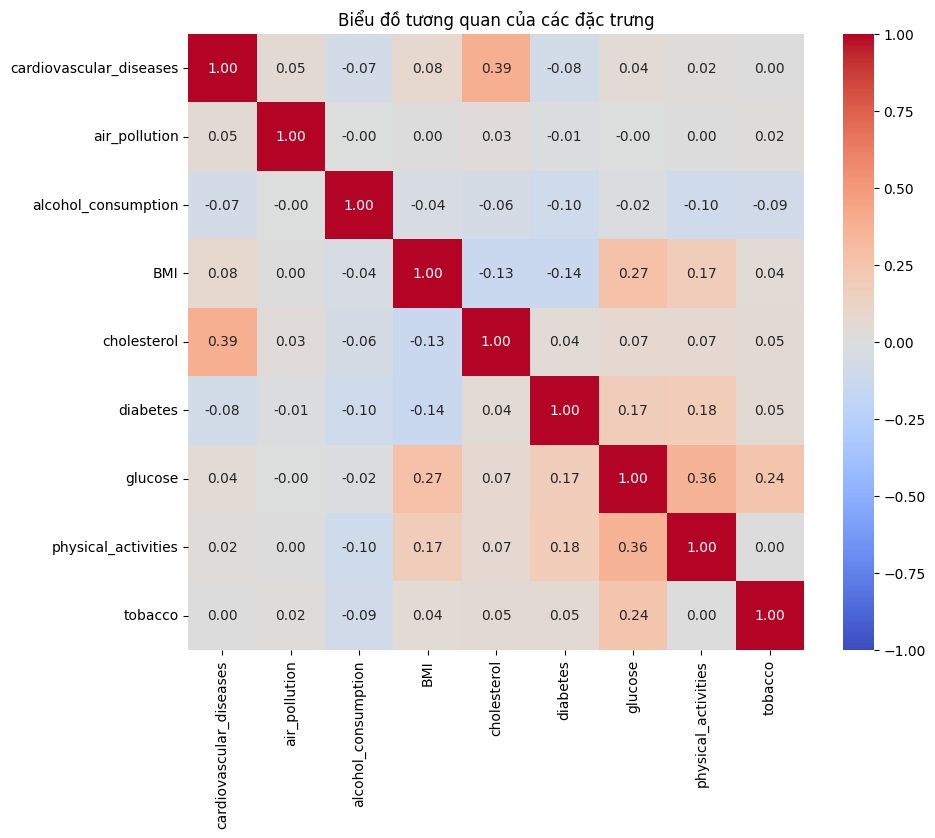

In [87]:
# Thử vẽ ma trận tương quan dữ liệu
# Diabetes là cột dữ liệu về kiểm soát nồng độ nên nó có tương quan âm với các thành phần còn lại
vars = tables.copy()
vars.pop()
vars.pop()

corr = df[vars].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,        # hiện giá trị corr
    fmt=".2f",
    cmap="coolwarm",   # thang màu phổ biến cho corr
    vmin=-1, vmax=1,
    square=True
)
plt.title("Biểu đồ tương quan của các đặc trưng")
plt.show()

In [88]:
# Tiến hành chia dữ liệu
df_model = df.copy()
y = df_model['cardiovascular_diseases']
df_model.drop(columns=['cardiovascular_diseases', 'country', 'time'], inplace=True)
X = df_model

In [89]:
# Thử tiến hành sử dụng mô hình lý giải
def run_for_linear(X, y):
    # Ko cần chia để test
    model = LinearRegression()
    model.fit(X, y)

    y_pred = model.predict(X)
    print("MSE:", mean_squared_error(y, y_pred))
    print("R2:", r2_score(y, y_pred))

    print("Coefficients:", model.coef_)
    print("Intercept:", model.intercept_)
    return model.coef_, model.intercept_

In [90]:
coef, inter = run_for_linear(X, y)

MSE: 1033.8361518130228
R2: 0.17892636854476296
Coefficients: [ 4.25320579e-06 -1.07855210e-01  2.43470234e-01  1.00693041e+01
 -1.82485166e-01  7.49409081e-02 -5.50388471e-02 -6.24571056e-02]
Intercept: 30.567490290937428


In [91]:
def softmax(z):
    z_shifted = z - np.max(z)   # tránh overflow
    exp_z = np.exp(z_shifted)
    return exp_z / np.sum(exp_z)

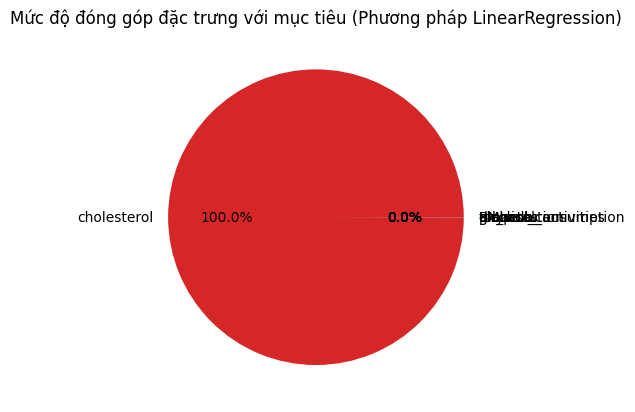

In [92]:
# Vẽ biểu đồ đối với Linear
# Thử vẽ biểu đồ đóng góp
# Biểu đồ này ko có ý nghĩa do ko giải thích được hết dữ liệu
plt.figure()
plt.pie(softmax(coef), labels=X.columns, autopct='%1.1f%%')
plt.title('Mức độ đóng góp đặc trưng với mục tiêu (Phương pháp LinearRegression)')
plt.show()

In [93]:
def run_for_random_forest(X, y):
    model = RandomForestRegressor(
        n_estimators=100,
        max_depth=None,
        random_state=42,
    )

    model.fit(X, y)
    y_pred = model.predict(X)
    print("MSE:", mean_squared_error(y, y_pred))
    print("R2:", r2_score(y, y_pred))

    print("Feature Importances:", model.feature_importances_)
    return model.feature_importances_

In [94]:
impor = run_for_random_forest(X, y)

MSE: 19.03020586601179
R2: 0.9848861928359292
Feature Importances: [0.01356633 0.03417121 0.47812032 0.26412724 0.09211119 0.07042079
 0.02066987 0.02681306]


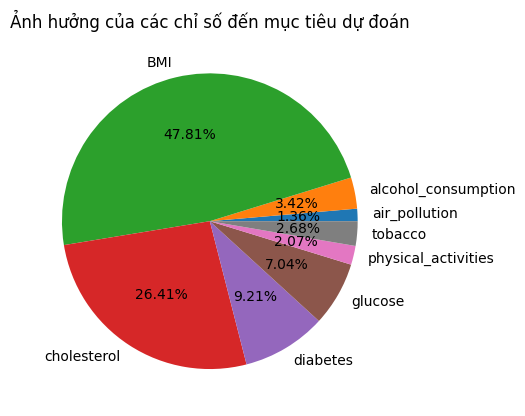

In [95]:
plt.figure()
plt.pie(impor.tolist(), labels=X.columns, autopct='%1.2f%%')
plt.title('Ảnh hưởng của các chỉ số đến mục tiêu dự đoán')
plt.show()

In [96]:
def draw_contribution(groups : dict = None, title=""):
    # Tiến hành tiền xử lí sơ sơ
    if groups is None:
        return

    mapping = dict()
    values = defaultdict(float)
    # Tạo bảng ánh xạ để hiển thị dữ liệu
    for name, comp in groups.items():
        for c in comp:
            mapping[c] = name

    # Định dạng của groups 
    # str --> tên groups
    for col, val in zip(X.columns, impor.tolist()):
        values[mapping[col]] += val

    # Thử vẽ biểu đồ đóng góp
    plt.figure()
    plt.pie(values.values(), labels=values.keys(), autopct='%1.2f%%')
    plt.title(title)
    plt.show()

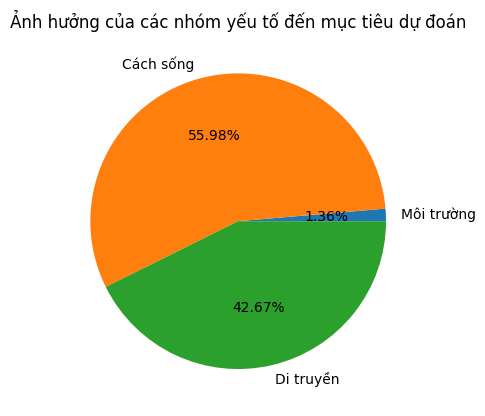

In [97]:
draw_contribution(groups={
    'Cách sống' : ['physical_activities', 'tobacco', 'alcohol_consumption', 'BMI'],
    'Môi trường' : ['air_pollution'],
    'Di truyền' : ['cholesterol', 'diabetes', 'glucose']
}, title="Ảnh hưởng của các nhóm yếu tố đến mục tiêu dự đoán")